# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ORM_AI_Agents_Bootcamp/blob/main/demo/DAY_1_DEMO_DAY_1_DEMO_SESSION_4_swarmsSESSION_1_LLM_state.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>



# About this Notebook

This notebook shows how to build and compile a **multi-agent swarm** using the `create_swarm` from [LangGraph Multi-Agent Swarm library](https://github.com/langchain-ai/langgraph-swarm-py). A swarm is a simple orchestration construct that allows multiple agents to collaborate, with one agent active by default and the others available to take over as needed.

## What it shows

* **Agent collaboration**: defines a swarm with two agents (`research_assistant` and `writer_assistant`).
* **Default active agent**: sets the `research_assistant` as the one that starts the conversation.
* **Compilation step**: calling `.compile()` finalizes the swarm into an executable app/graph that can process inputs and route them between agents.

## How it works

1. **Define agents**: elsewhere in the code, `research_assistant` and `writer_assistant` are each defined as tool-enabled agents with their own prompts or roles.
2. **Swarm creation**: `create_swarm()` takes these agent objects and constructs a collaborative structure.
3. **Default activation**: `default_active_agent="research_assistant"` ensures that research is initiated first, and only when needed does control move to the `writer_assistant`.
4. **Compilation**: `.compile()` returns a runnable object (often a LangGraph app) that manages state, routing, and message passing across agents.

## Why this pattern

* Keeps roles **modular**: each agent has its own tools and responsibilities.
* Provides **coordination**: the swarm acts as a supervisor that manages turn-taking.
* Easy to **extend**: more agents (editors, reviewers, validators) can be added without changing the orchestration logic.

## Extend and adapt

* Add a **validator agent** to check factual accuracy before the writer finalizes.
* Change the **default active agent** if you want drafting to begin before research.
* Add **routing rules** or scoring functions to decide which agent to hand off to.
* Persist swarm state with a checkpointer so multi-turn tasks can span sessions.

## Requirements and notes

* Requires `langgraph_swarm` or equivalent utilities installed.
* The agents passed to `create_swarm` must already be defined and tool-bound.
* Swarm behavior depends on how the agents are prompted—clear role definitions improve collaboration.

In [ ]:
!pip install -q \
    langchain==0.3.27 \
    langgraph==0.6.7 \
    langchain-openai==0.3.33 \
    langchain_experimental==0.3.4 \
    langchain_community==0.3.30 \
    langchain-tavily==0.2.11 \
    python-dotenv==1.1.1 \
    langchain-core \
    langgraph-swarm==0.0.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

# API Key Setup

In [ ]:
# Option 1 (preferred): create a `.env` file in your project folder with:
# OPENAI_API_KEY=your_openai_key_here
# TAVILY_API_KEY=your_tavily_key_here
#
# Option 2: set it directly in the notebook with magic:
# %env OPENAI_API_KEY=your_openai_key_here
# %env TAVILY_API_KEY=your_tavily_key_here

from dotenv import load_dotenv
import os

# Load from .env if available
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

# Fallback: ask if still missing
if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

if not TAVILY_API_KEY:
    print("⚠️ TAVILY_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    TAVILY_API_KEY = input("Enter your TAVILY_API_KEY: ").strip()

print("✅ API keys loaded successfully!")


✅ API keys loaded successfully!


# Imports

In [ ]:
import os
from typing import Annotated, List
from uuid import uuid4
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch

from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_swarm, create_handoff_tool


# Tools

In [ ]:
# Tavily web search
tavily_tool = TavilySearch(max_results=5).as_tool()

MAX_URLS_TO_SCRAPE = 1
MAX_CHARS_PER_SOURCE = 2000
MAX_TOTAL_SCRAPE_CHARS = 2000


def _compact_text(text: str, limit: int) -> str:
    cleaned = " ".join(text.split())
    if len(cleaned) <= limit:
        return cleaned
    return cleaned[:limit] + " ..."


@tool
def scrape_webpages(urls: List[str]) -> str:
    """Scrape one page and return a compact evidence card instead of a full page dump."""
    try:
        loader = WebBaseLoader(urls[:MAX_URLS_TO_SCRAPE])
        docs = loader.load()
    except Exception as exc:
        return f"Scrape failed: {exc}"

    if not docs:
        return "Scrape returned no content."

    doc = docs[0]
    snippet = _compact_text(doc.page_content, MAX_CHARS_PER_SOURCE)

    return "\n".join(
        [
            f"Title: {doc.metadata.get('title', 'Untitled')}",
            f"Source: {doc.metadata.get('source', 'Unknown source')}",
            "Evidence snippet:",
            snippet,
        ]
    )


/tmp/ipykernel_342/2148249003.py:2: LangChainBetaWarning: This API is in beta and may change in the future.
  tavily_tool = TavilySearch(max_results=5).as_tool()


# Handoff tools

In [ ]:
to_writer = create_handoff_tool(
    agent_name="writer_assistant",
    description="Transfer to the writing assistant once the research brief is compact and sufficient.",
)
to_research = create_handoff_tool(
    agent_name="research_assistant",
    description="Return to the research assistant only if a specific evidence gap remains.",
)

# LLM config

In [ ]:
# Uses OpenAI through LangChain. Set OPENAI_API_KEY in your environment.
agent_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    model_kwargs={"parallel_tool_calls": False},
)

synthesis_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

# Agents

In [ ]:
research_assistant = create_react_agent(
    model=agent_llm,
    tools=[tavily_tool, scrape_webpages, to_writer],
    prompt=(
        "You are a lightweight research assistant in a bounded swarm. "
        "Search with Tavily first, then optionally scrape only the single most relevant URL. "
        "Never paste raw page dumps into the conversation. Compress every finding into short evidence notes with source names and URLs. "
        "Use at most one tool call per turn. Never call scrape_webpages and the handoff tool in the same turn. Always wait for the tool result before choosing the next action. "
        "Stop as soon as you have 3 authoritative sources and then hand off to the writer assistant."
    ),
    name="research_assistant",
)

writer_assistant = create_react_agent(
    model=agent_llm,
    tools=[to_research],
    prompt=(
        "You are the synthesis assistant for a bounded swarm. "
        "Use only the compact research notes already in the thread. "
        "Produce a concise answer with exactly 3 bullet points and a short references list. "
        "Use at most one tool call per turn. If evidence is missing, hand back to research with one specific gap request and do only that. Do not repeat long excerpts."
    ),
    name="writer_assistant",
)

# Swarm

In [ ]:
swarm = create_swarm(
    agents=[research_assistant, writer_assistant],
    default_active_agent="research_assistant",
).compile()

# Run a bounded swarm

## Why the guardrails matter

Raw multi-agent transcripts grow quickly: every handoff, tool result, and intermediate draft is appended to shared state.

That is why parallel exploration needs guardrails. Many lightweight agents improve coverage and signal validation, but without strict exit conditions and a downstream aggregator, the swarm can hit token limits fast.

In practice, the problem is not that swarms are a bad idea. The problem is that they generate a lot of intermediate context. If each agent forwards large search results, long page scrapes, and repeated summaries, the shared conversation becomes too large and expensive to maintain.

## Why use swarms anyway

Swarms are still valuable because they let multiple agents explore different angles of a problem, cross-check findings, and specialize by role.

This can improve:

- coverage across sources or hypotheses
- redundancy for higher confidence and better signal validation
- modularity, since researchers and synthesizers can stay focused on different tasks
- speed, especially when exploration can happen in parallel

## The practical pattern

The right pattern is not unlimited agent chatter. It is broad exploration followed by aggressive compression and a final synthesis step.

This demo uses three protections:

- compact evidence cards instead of full scraped pages
- a strict recursion limit for the swarm
- a downstream consolidator that synthesizes only compressed agent notes
- a fresh `thread_id` on each run so interrupted notebook executions do not reuse partial tool-call state

## Pattern diagram

```text
User request
    |
    v
Parallel swarm exploration
(multiple lightweight agents)
    |
    v
Compact evidence notes
(short findings, URLs, key facts)
    |
    v
Downstream consolidator
(single synthesis pass)
    |
    v
Final answer
```

This is the core idea: let the swarm explore broadly, but only pass compressed notes into the final synthesis stage.

In [ ]:
MAX_SWARM_TURNS = 8
MAX_NOTE_CHARS = 1800


def _message_to_text(message) -> str:
    content = getattr(message, "content", "")
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, dict) and item.get("type") == "text":
                parts.append(item.get("text", ""))
            else:
                parts.append(str(item))
        return "\n".join(parts)
    return str(content)


def extract_compact_agent_notes(result: dict, keep_last: int = 6) -> str:
    notes = []
    for message in result["messages"]:
        name = getattr(message, "name", "")
        if name not in {"research_assistant", "writer_assistant"}:
            continue

        text = _message_to_text(message).strip()
        if not text:
            continue

        notes.append(f"{name}:\n{text[:MAX_NOTE_CHARS]}")

    return "\n\n".join(notes[-keep_last:])


def consolidate_swarm_notes(compact_notes: str) -> str:
    consolidation_prompt = (
        "You are the downstream aggregator for a swarm of lightweight research agents. "
        "Synthesize only the compact notes below into a final answer. "
        "Do not expand the context by repeating raw source text. "
        "Return exactly three bullet points, then a short references list.\n\n"
        f"Compact notes:\n{compact_notes}"
    )
    return synthesis_llm.invoke(consolidation_prompt).content


user_request = {
    "messages": [
        {
            "role": "user",
            "content": (
                "Find the current Swiss fintech licensing options for small startups. "
                "Gather authoritative sources and produce a short summary with three bullet points and references."
            ),
        }
    ]
}

run_config = {
    "recursion_limit": MAX_SWARM_TURNS,
    "configurable": {
        "thread_id": f"swarm-demo-{uuid4()}"
    },
}

swarm_run = create_swarm(
    agents=[research_assistant, writer_assistant],
    default_active_agent="research_assistant",
).compile()

result = swarm_run.invoke(user_request, config=run_config)
compact_notes = extract_compact_agent_notes(result)
final_answer = consolidate_swarm_notes(compact_notes)

print("=== Run config ===")
print(run_config)
print()
print("=== Compact swarm notes ===")
print(compact_notes)
print()
print("=== Downstream consolidated answer ===")
print(final_answer)


=== Run config ===
{'recursion_limit': 8, 'configurable': {'thread_id': 'swarm-demo-04e51542-ea7b-4902-aef9-908b35c0f9ff'}}

=== Compact swarm notes ===
writer_assistant:
- The Swiss Fintech Licence, introduced under Article 1b of the Swiss Banking Act, allows startups to accept public deposits up to CHF 100 million without engaging in lending or asset management, providing a flexible regulatory framework for innovative financial services.
- Startups can also benefit from a sandbox regime that permits accepting public deposits of up to CHF 1 million without a banking license, fostering innovation while ensuring regulatory compliance.
- As of early 2024, there are five active fintech license holders in Switzerland, with the regulatory authority (FINMA) maintaining a cautious approach to licensing to protect depositors.

### References
1. [The Swiss Fintech Licence 2024: An Overview - Aml Compliance](https://www.aml-compliance.ch/post/the-swiss-fintech-licence-2024-an-overview)
2. [How t

In [ ]:
# Plot graph

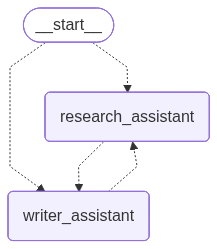

In [ ]:
from IPython.display import Image, display

display(Image(swarm.get_graph().draw_mermaid_png()))